In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from qubo_utils import build_Q,check_validity,execute_qaoa_and_get_results,linear_ramp_parameters

edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]

costs = [2,4,1,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,   # source
    4: -1,  # sink
    1: 0,
    2: 0,
    3: 0
}

Q = build_Q(costs, edges, nodes, targets)
print(Q.shape)
print(Q)

(7, 7)
[[ 2.  6. -6. -6.  0.  0.  0.]
 [ 0.  4.  6.  0. -6. -6.  0.]
 [ 0.  0.  7.  6. -6. -6.  0.]
 [ 0.  0.  0.  9.  6.  0. -6.]
 [ 0.  0.  0.  0.  8.  6. -6.]
 [ 0.  0.  0.  0.  0.  5.  6.]
 [ 0.  0.  0.  0.  0.  0.  1.]]


The constructed 7×7 QUBO matrix is used as input for QAOA.

In [2]:
from qat.opt import QUBO
import numpy as np

# Make Q symmetric
Q = -((Q + Q.T) / 2)

print("Q matrix:")
print(Q)

# Create QUBO object
qubo = QUBO(Q)

Q matrix:
[[-2. -3.  3.  3. -0. -0. -0.]
 [-3. -4. -3. -0.  3.  3. -0.]
 [ 3. -3. -7. -3.  3.  3. -0.]
 [ 3. -0. -3. -9. -3. -0.  3.]
 [-0.  3.  3. -3. -8. -3.  3.]
 [-0.  3.  3. -0. -3. -5. -3.]
 [-0. -0. -0.  3.  3. -3. -1.]]


The matrix is made symmetric and its sign is flipped to convert the problem into a maximization form required by QAOA.Finally, the matrix is converted into a QUBO object.    

In [3]:
from qat.qpus import get_default_qpu
#Initialize QPU
qpu = get_default_qpu()

# Different QAOA depths to analyze performance
depths = [1, 2, 3, 4, 5, 6, 7, 8]
best_probs = []

# Store best solution details for each depth
best_results = []

for dep in depths:
    # Create QAOA job for current depth
    job = qubo.qaoa_job(dep,False)

    #print(job.get_variables())
    circuit = job.circuit

    # Linear-ramp schedule parameters
    delta_beta = 0.5
    delta_gamma = -0.5

    # Generate fixed LR-QAOA parameters
    param_map = linear_ramp_parameters(dep, delta_beta, delta_gamma)

    # Execute final circuit with optimized parameters
    bitstrings, probabilities, final_result = execute_qaoa_and_get_results(circuit, qpu, param_map, Q,nbshots =0)

    costs_list = []
    valid_flags = []

    num_edges = len(edges)

    for sample in final_result:

      bitstring = sample.state.bitstring.zfill(Q.shape[0])

      edge_bits = bitstring[:num_edges]

      bits = [int(b) for b in edge_bits]   # convert to list of ints

      path_cost = sum(costs[i] for i, b in enumerate(bits) if b == 1)

      valid = check_validity(bits, edges, nodes, targets)

      costs_list.append(path_cost)
      valid_flags.append(valid)


    # Print valid solutions
    for b, c, v, p in zip(bitstrings, costs_list, valid_flags,probabilities):
     if v:
        print("Depth:", dep,"|Bitstring:", b, "| Path cost:", c,"| Probability:", p,"| Valid:",v)

    best_cost = float('inf')
    best_bitstring = None
    best_prob = -1

  # Find the best valid solution
    for c, v, b, p in zip(costs_list, valid_flags, bitstrings, probabilities):
      if v:
          if (c < best_cost) or (c == best_cost and p > best_prob):
              best_cost = c
              best_bitstring = b
              best_prob = p

    if best_bitstring is not None:
      bits = [int(b) for b in best_bitstring]
      edge_bits = bits[:num_edges]

      best_path_edges = [
      edges[i] for i, b in enumerate(edge_bits) if b == 1
      ]
      best_results.append({
        "depth": dep,
        "bitstring": best_bitstring,
        "cost": best_cost,
        "path": best_path_edges,
        "probability": best_prob
      })
      
    # Store probability of best valid solution  
    best_probs.append(best_prob)     


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Depth: 1 |Bitstring: 0100010 | Path cost: 9 | Probability: 0.03773120756543496 | Valid: True
Depth: 1 |Bitstring: 0100101 | Path cost: 7 | Probability: 0.03583535865392211 | Valid: True
Depth: 1 |Bitstring: 1001001 | Path cost: 6 | Probability: 0.04042431939152214 | Valid: True
Depth: 1 |Bitstring: 1010010 | Path cost: 8 | Probability: 0.035225216773470056 | Valid: True
Depth: 1 |Bitstring: 1010101 | Path cost: 6 | Probability: 0.0357433986196522 | Valid: True
Depth: 2 |Bitstring: 0100010 | Path cost: 9 | Probability: 0.045815824678478154 | Valid: True
Depth: 2 |Bitstring: 0100101 | Path cost: 7 | Probability: 0.05164111523790987 | Valid: True
Depth: 2 |Bitstring: 1001001 | Path cost: 6 | Probability: 0.054969675789031204 | Valid: True
Depth: 2 |Bitstring: 1010010 | Path cost: 8 | Probability: 0.04746288024611916 | Valid: True
Depth: 2 |Bitstring: 1010101 | Path cost: 6 | Probability: 0.05620194713528334 | Valid: True
Depth: 3 |Bitstring: 0100010 | Path cost: 9 | Probability: 0.0475171

QAOA Depth Analysis for the QUBO Problem - The Linear-Ramp QAOA (LR-QAOA) approach is executed for multiple circuit depths to analyze how the solution quality changes with increasing depth. Instead of using classically optimized QAOA parameters, predefined linear-ramp schedules are used for the mixer Hamiltonian (β) and cost Hamiltonian (γ). This removes the need for the classical optimization loop and reduces sensitivity to random parameter initialization.

For each QAOA depth:

* The LR-QAOA circuit is generated for the corresponding depth.
* Fixed linear-ramp parameters are generated and assigned to the circuit.
* The circuit is executed on the QPU simulator.
* Measured bitstrings and their probabilities are extracted.
* Path costs are computed from the selected edges.
* Validity constraints are checked to identify feasible solutions.
* All valid solutions are printed for each QAOA depth along with the depth number, path cost, probability, and validity status.
* The best valid solution is selected based on:
  1. Minimum path cost
  2. Highest probability in case of equal costs
* The probability of the best valid solution is stored.


In [4]:
best_valid_solution = None

for result in best_results:

    if best_valid_solution is None:

        best_valid_solution = result

    elif result["cost"] < best_valid_solution["cost"]:

        best_valid_solution = result

    elif (result["cost"] == best_valid_solution["cost"] and
          result["probability"] > best_valid_solution["probability"]):

        best_valid_solution = result

print("Overall Best Valid Solution")
print("Best Valid Bitstring:", best_valid_solution["bitstring"])
print("Minimum Path Cost:", best_valid_solution["cost"])
print("QAOA Depth:", best_valid_solution["depth"])
print("Best Valid Path:", best_valid_solution["path"])
print("Probability of Best Solution:", best_valid_solution["probability"])

Overall Best Valid Solution
Best Valid Bitstring: 1010101
Minimum Path Cost: 6
QAOA Depth: 7
Best Valid Path: [(0, 1), (1, 2), (2, 3), (3, 4)]
Probability of Best Solution: 0.10037931779063566


The best valid solution across all QAOA depths is selected based on the minimum path cost and maximum probability. The corresponding bitstring, path, depth, and probability are printed.

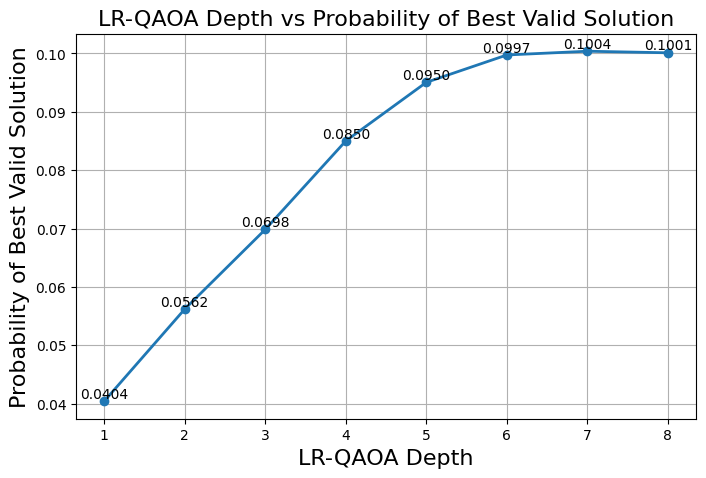

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(depths, best_probs,
         marker='o',
         linewidth=2)

# Show probability values on graph
for d, prob in zip(depths, best_probs):

    plt.text(d,
             prob,
             f"{prob:.4f}",
             ha='center',
             va='bottom')

plt.xlabel("LR-QAOA Depth", fontsize=16)
plt.ylabel("Probability of Best Valid Solution", fontsize=16)

plt.title("LR-QAOA Depth vs Probability of Best Valid Solution", fontsize=16)

plt.grid(True)

plt.show()

Analysis of Probability of the Best Valid Solution vs LR-QAOA Depth

* To evaluate the effect of circuit depth on the LR-QAOA performance, the probability of obtaining the best valid solution is analyzed for different LR-QAOA depths.
* For each depth, the valid solution with the minimum path cost is selected. In cases where multiple valid solutions have the same cost, the solution with the highest measurement probability is chosen as the best solution for that depth.
* The following plot illustrates the relationship between the LR-QAOA depth and the probability of measuring the best valid solution. The probability values are additionally annotated on the graph for clearer comparison across different depths.
